In [ ]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn mlxtend openpyxl

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Uber.xlsx to Uber (2).xlsx


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.cluster import KMeans

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

In [ ]:
# Load Excel sheets
trip_df = pd.read_excel('Uber.xlsx', sheet_name='Trip Details')
location_df = pd.read_excel('Uber.xlsx', sheet_name='Location Table')
rides_df = pd.read_excel('Uber.xlsx', sheet_name='Uber Rides Data')

# Basic info
print("Trip Data:", trip_df.shape)
print("Location Data:", location_df.shape)
print("Rides Data:", rides_df.shape)

Trip Data: (103728, 11)
Location Data: (265, 3)
Rides Data: (1141, 17)


In [ ]:
# Feature Engineering
# Convert to datetime
trip_df['Pickup Time'] = pd.to_datetime(trip_df['Pickup Time'])
trip_df['Drop Off Time'] = pd.to_datetime(trip_df['Drop Off Time'])

# Create features
trip_df['pickup_hour'] = trip_df['Pickup Time'].dt.hour
trip_df['trip_duration'] = (
    (trip_df['Drop Off Time'] - trip_df['Pickup Time'])
    .dt.total_seconds() / 60
)

trip_df.head()

,Trip ID,Pickup Time,Drop Off Time,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,Surge Fee,Vehicle,Payment_type,pickup_hour,trip_duration
0,1,2024-06-01 00:42:50,2024-06-01 01:04:33,1,5.60,79,226,19.5,2.0,UberX,Uber Pay,0,21.716667
1,2,2024-06-01 00:06:29,2024-06-01 00:13:22,1,1.72,142,186,8.0,0.0,Uber Black,Cash,0,6.883333
2,3,2024-06-01 00:08:05,2024-06-01 00:21:33,1,3.41,229,238,13.0,0.0,Uber Black,Cash,0,13.466667
3,4,2024-06-01 00:28:20,2024-06-01 00:37:46,1,1.81,188,35,9.0,0.0,UberX,Cash,0,9.433333
4,5,2024-06-01 00:38:05,2024-06-01 00:45:05,1,1.89,100,137,8.0,0.0,Uber Black,Cash,0,7.000000


In [ ]:
# PART 1: DECISION TREE
# Train Model
# Select features (input)
X = trip_df[['trip_distance', 'passenger_count', 'fare_amount',
             'Surge Fee', 'pickup_hour', 'trip_duration']]

# Target (output)
y = trip_df['Payment_type']

# Handle missing values
X = X.fillna(X.median())

# Convert target to numbers
le = LabelEncoder()
y = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Train Decision Tree
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9572287027218098
Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.04      0.08       192
           1       0.88      1.00      0.94     10136
           2       0.00      0.00      0.00        59
           3       1.00      0.95      0.97     20732

    accuracy                           0.96     31119
   macro avg       0.64      0.50      0.50     31119
weighted avg       0.96      0.96      0.95     31119



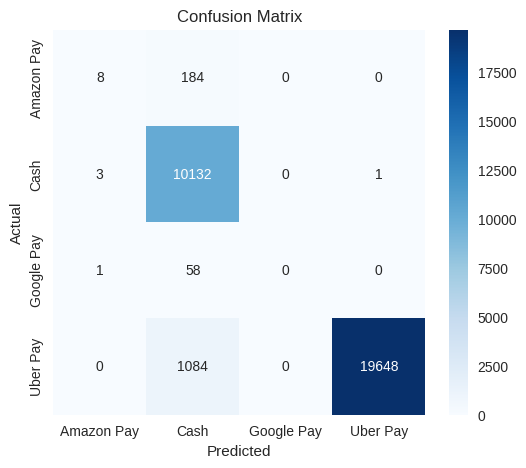

In [ ]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

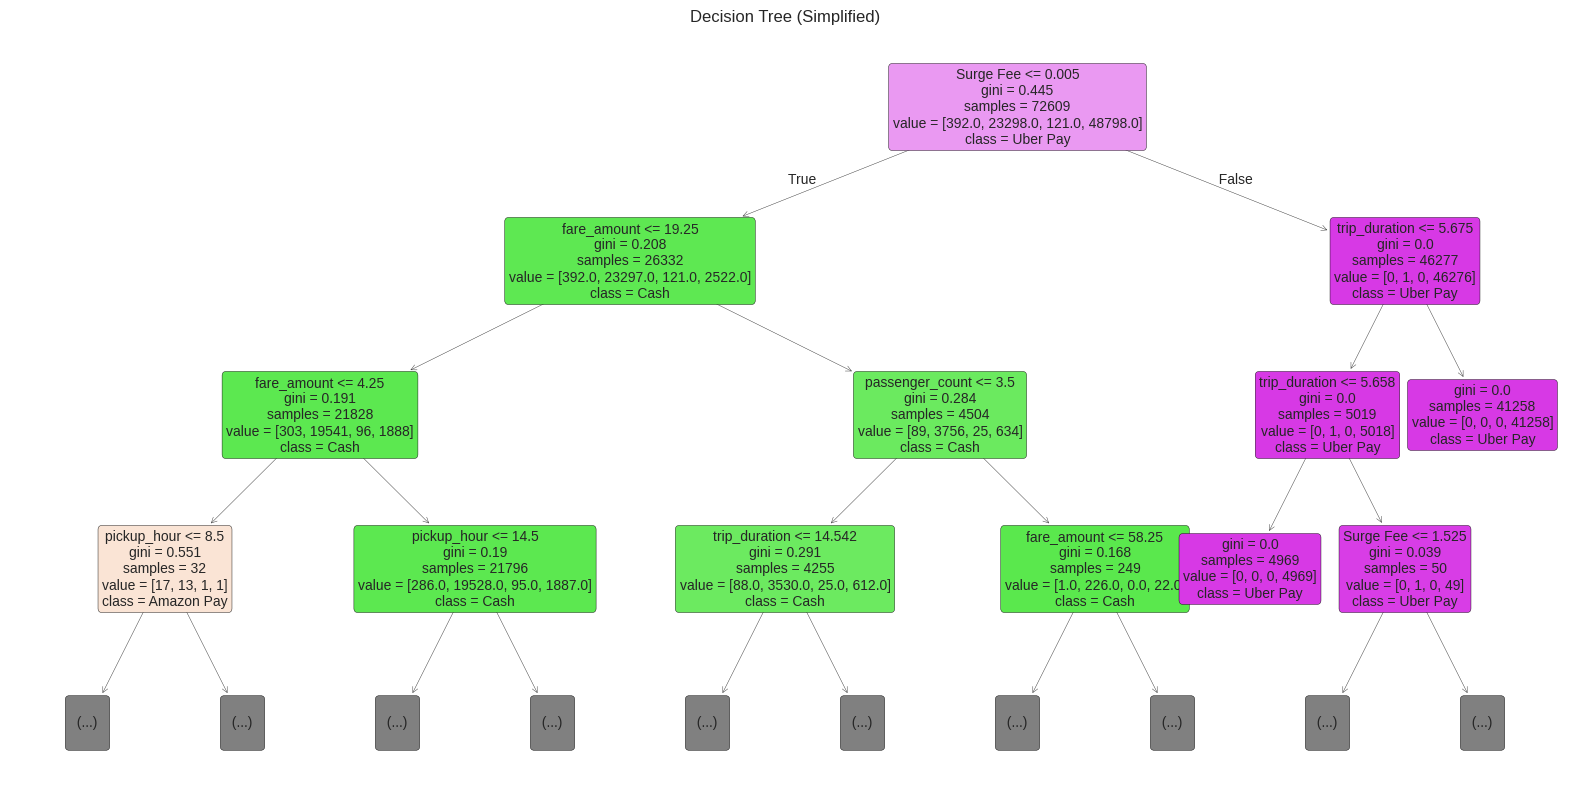

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3   # keeps it readable
)

plt.title("Decision Tree (Simplified)")
plt.show()

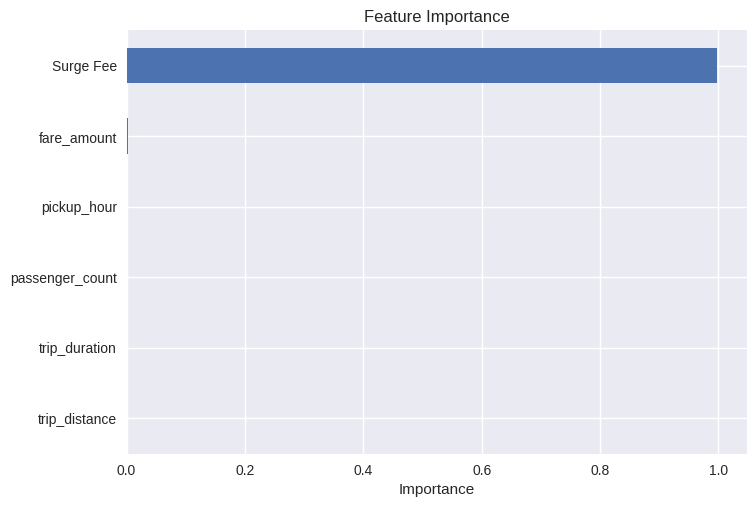

In [ ]:
# Importance of features
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.show()

In [ ]:
# PART 2: CLUSTERING (K-MEANS)
# Select features
features = ['trip_distance', 'fare_amount', 'trip_duration',
            'passenger_count', 'Surge Fee']

X_cluster = trip_df[features].fillna(trip_df[features].median())

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Apply KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
trip_df['cluster'] = kmeans.fit_predict(X_scaled)

# Check cluster count
print(trip_df['cluster'].value_counts())

cluster
0    83513
1    11715
3     8287
2      213
Name: count, dtype: int64


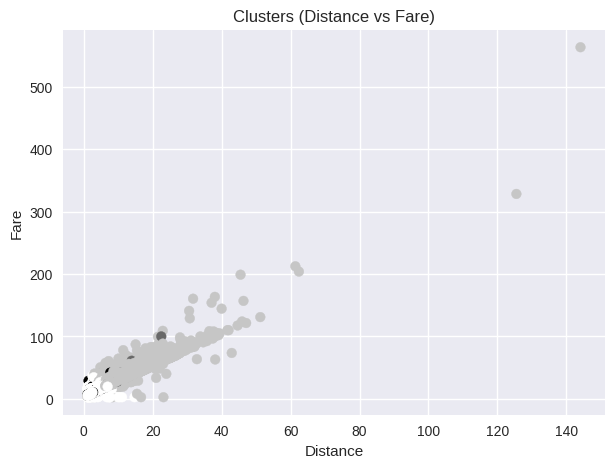

In [ ]:
# Cluster Visualization
# Scatter plot
plt.figure(figsize=(7,5))

plt.scatter(
    trip_df['trip_distance'],
    trip_df['fare_amount'],
    c=trip_df['cluster']
)

plt.xlabel("Distance")
plt.ylabel("Fare")
plt.title("Clusters (Distance vs Fare)")
plt.show()

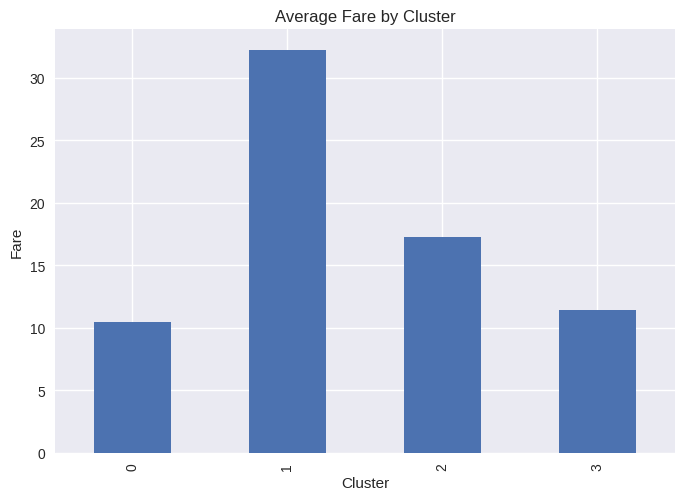

In [ ]:
# Cluster Comparison Chart
# Average fare per cluster
trip_df.groupby('cluster')['fare_amount'].mean().plot(kind='bar')

plt.title("Average Fare by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Fare")
plt.show()

In [ ]:
# PART 3: ASSOCIATION ANALYSIS
# Prepare Data
# Create categories
trip_df['distance_cat'] = pd.cut(trip_df['trip_distance'],
                                bins=[0,2,5,10,100],
                                labels=['Short','Medium','Long','Very_Long'])

trip_df['fare_cat'] = pd.cut(trip_df['fare_amount'],
                            bins=[0,10,20,30,100],
                            labels=['Low','Medium','High','Very_High'])

In [ ]:
# Transactions
transactions = []

for _, row in trip_df.iterrows():
    transactions.append([
        f"Vehicle_{row['Vehicle']}",
        f"Payment_{row['Payment_type']}",
        f"Distance_{row['distance_cat']}",
        f"Fare_{row['fare_cat']}"
    ])

In [ ]:
# Apply Apriori
# Convert to one-hot
te = TransactionEncoder()
df = pd.DataFrame(te.fit(transactions).transform(transactions),
                  columns=te.columns_)

# Frequent itemsets
freq_items = apriori(df, min_support=0.1, use_colnames=True)

print(freq_items.head())

    support           itemsets
0  0.121356    (Distance_Long)
1  0.404134  (Distance_Medium)
2  0.429344   (Distance_Short)
3  0.514692         (Fare_Low)
4  0.349481      (Fare_Medium)


In [ ]:
# Association Rules
rules = association_rules(freq_items, metric="confidence", min_threshold=0.5)

print(rules[['antecedents','consequents','support','confidence','lift']].head())

         antecedents         consequents   support  confidence      lift
0      (Fare_Medium)   (Distance_Medium)  0.299196    0.856114  2.118393
1  (Distance_Medium)       (Fare_Medium)  0.299196    0.740339  2.118393
2  (Distance_Medium)  (Payment_Uber Pay)  0.278642    0.689480  1.028597
3   (Distance_Short)          (Fare_Low)  0.413890    0.964006  1.872975
4         (Fare_Low)    (Distance_Short)  0.413890    0.804151  1.872975


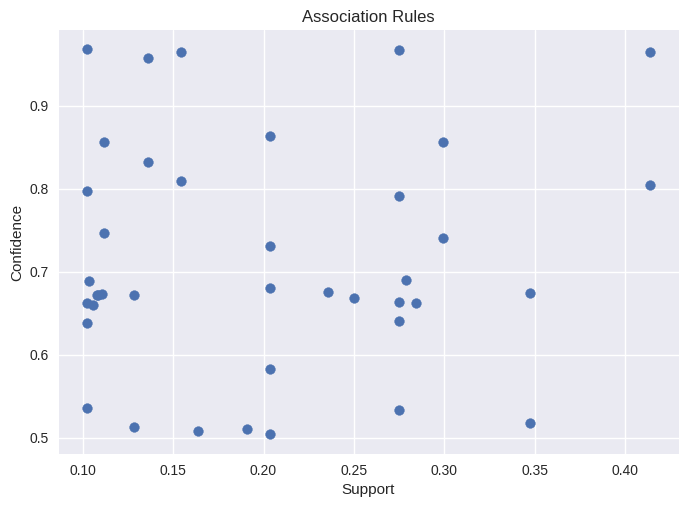

In [ ]:
# Simple Association Chart
# Support vs Confidence
plt.scatter(rules['support'], rules['confidence'])

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Association Rules")
plt.show()

In [ ]:
# Summary
print("Total Trips:", len(trip_df))
print("Average Distance:", trip_df['trip_distance'].mean())
print("Average Fare:", trip_df['fare_amount'].mean())
print("Clusters:", trip_df['cluster'].nunique())

Total Trips: 103728
Average Distance: 3.363930761221657
Average Fare: 12.998336514730832
Clusters: 4
